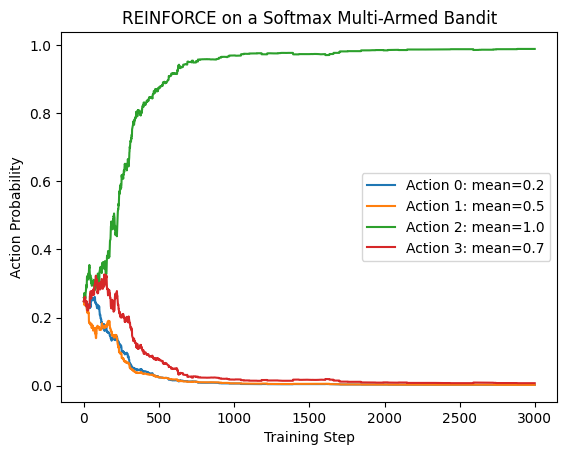

In [1]:
import numpy as np
import matplotlib.pyplot as plt


rng = np.random.default_rng(0)

# 四个老虎机臂真实的 expected reward
# Agent 并不知道这些值，只能通过不断尝试获得 noisy reward
true_means = np.array([0.2, 0.5, 1.0, 0.7])

num_actions = len(true_means)

# Policy 参数：softmax logits
theta = np.zeros(num_actions)

learning_rate = 0.05

# running baseline
baseline = 0.0
baseline_lr = 0.05

steps = 3000

prob_history = []


def softmax(x):
    x = x - np.max(x)
    exp_x = np.exp(x)
    return exp_x / exp_x.sum()


for step in range(steps):

    # 1. 当前 Policy
    probs = softmax(theta)

    # 2. 根据 Policy 采样 action
    action = rng.choice(num_actions, p=probs)

    # 3. Environment 返回 noisy reward
    reward = rng.normal(
        loc=true_means[action],
        scale=1.0
    )

    # 4. 计算 grad log pi(a)
    #
    # 对 softmax：
    #
    # d log pi(a) / d theta_k
    # =
    # 1[k == a] - pi(k)
    #
    grad_log_pi = -probs.copy()
    grad_log_pi[action] += 1.0

    # 5. REINFORCE + baseline
    #
    # 注意：先使用“旧 baseline”计算 advantage，
    # 再使用当前 reward 更新 baseline。
    advantage = reward - baseline

    # Gradient Ascent
    theta += learning_rate * advantage * grad_log_pi

    # 6. 更新 running baseline
    baseline += baseline_lr * (reward - baseline)

    prob_history.append(softmax(theta))


prob_history = np.array(prob_history)

for action in range(num_actions):
    plt.plot(
        prob_history[:, action],
        label=f"Action {action}: mean={true_means[action]}"
    )

plt.xlabel("Training Step")
plt.ylabel("Action Probability")
plt.title("REINFORCE on a Softmax Multi-Armed Bandit")
plt.legend()
plt.show()